In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from  sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score ,f1_score, recall_score,precision_score, classification_report, confusion_matrix

In [5]:
df=pd.read_csv("dataset_35_dermatology (1).csv")
df

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3


In [6]:
df.shape

(366, 35)

In [7]:
pd.set_option('display.max_columns',None)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

In [9]:
df.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
erythema,366.0,2.068306,0.664753,0.0,2.0,2.0,2.0,3.0
scaling,366.0,1.795082,0.701527,0.0,1.0,2.0,2.0,3.0
definite_borders,366.0,1.549180,0.907525,0.0,1.0,2.0,2.0,3.0
itching,366.0,1.366120,1.138299,0.0,0.0,1.0,2.0,3.0
koebner_phenomenon,366.0,0.633880,0.908016,0.0,0.0,0.0,1.0,3.0
polygonal_papules,366.0,0.448087,0.957327,0.0,0.0,0.0,0.0,3.0
follicular_papules,366.0,0.166667,0.570588,0.0,0.0,0.0,0.0,3.0
oral_mucosal_involvement,366.0,0.377049,0.834147,0.0,0.0,0.0,0.0,3.0
knee_and_elbow_involvement,366.0,0.614754,0.982979,0.0,0.0,0.0,1.0,3.0
scalp_involvement,366.0,0.519126,0.905639,0.0,0.0,0.0,1.0,3.0


In [12]:
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45,3


In [13]:
df['Age'].unique()

array(['55', '8', '26', '40', '45', '41', '18', '57', '22', '30', '20',
       '21', '10', '65', '38', '23', '17', '51', '42', '44', '33', '43',
       '50', '34', '?', '15', '46', '62', '35', '48', '12', '52', '60',
       '32', '19', '29', '25', '36', '13', '27', '31', '28', '64', '39',
       '47', '16', '0', '7', '70', '37', '61', '67', '56', '53', '24',
       '58', '49', '63', '68', '9', '75'], dtype=object)

In [14]:
df[df['Age']=='?']

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
33,2,2,1,0,0,0,0,0,1,0,1,0,0,2,0,0,2,1,2,2,1,2,0,1,0,0,0,0,0,0,0,0,0,?,1
34,2,1,0,0,2,0,0,0,0,0,0,0,0,0,0,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,?,4
35,2,2,1,2,0,0,0,0,0,0,0,0,0,2,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,?,2
36,2,1,2,3,2,3,0,2,0,0,1,1,0,0,0,2,1,1,2,0,0,0,0,0,1,0,2,0,2,0,0,0,3,?,3
262,2,1,0,2,0,0,0,0,0,0,0,0,0,0,2,1,3,2,2,1,3,0,0,0,0,0,0,2,0,0,0,3,0,?,5
263,1,1,1,3,0,0,0,0,0,0,0,0,0,0,3,2,3,1,2,2,2,0,0,0,0,0,0,3,0,0,0,2,0,?,5
264,1,1,0,2,0,0,0,0,1,0,0,0,0,0,3,2,3,2,1,1,3,0,0,0,0,0,0,2,0,0,0,3,0,?,5
265,1,1,0,3,0,0,0,0,0,0,0,0,0,0,2,1,3,1,1,0,2,0,1,0,0,0,0,2,0,0,0,3,0,?,5


In [15]:
df["Age"] = df["Age"].replace('?', np.nan)
df["Age"] = df["Age"].astype("Int64")

In [16]:
df['Age'].isnull().sum()

np.int64(8)

In [17]:
df['Age']=df['Age'].fillna(df['Age'].median())

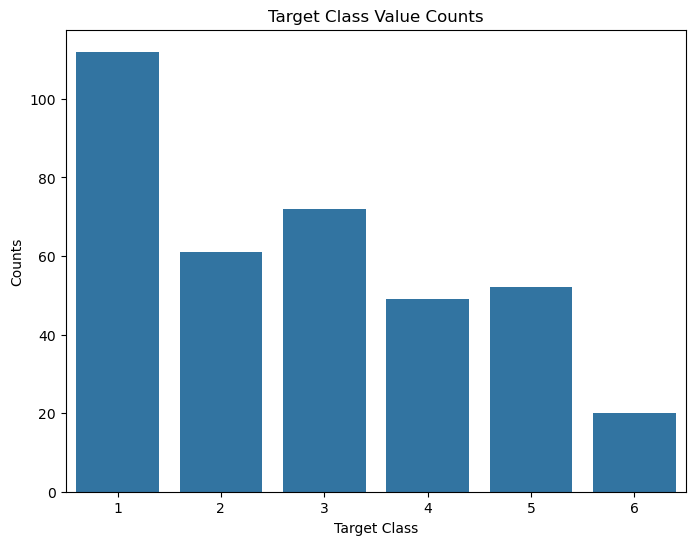

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.countplot(x='class', data=df) 
plt.title("Target Class Value Counts")
plt.xlabel("Target Class")
plt.ylabel("Counts")
plt.show()

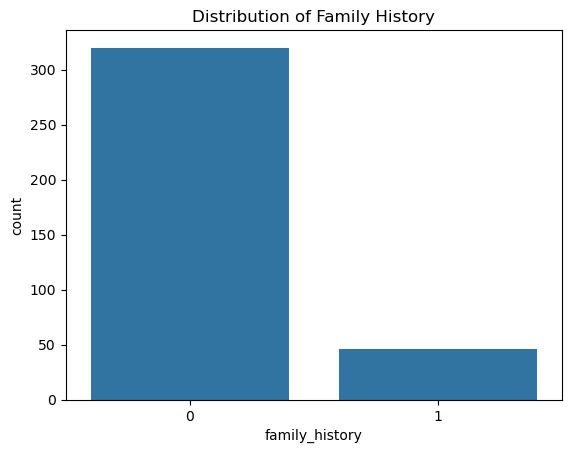

In [19]:
sns.countplot(x='family_history', data=df)
plt.title("Distribution of Family History")
plt.show()

In [20]:
family_vs_disease = pd.crosstab(df['family_history'], df['class'])
print(family_vs_disease)

class            1   2   3   4   5   6
family_history                        
0               80  58  71  49  52  10
1               32   3   1   0   0  10


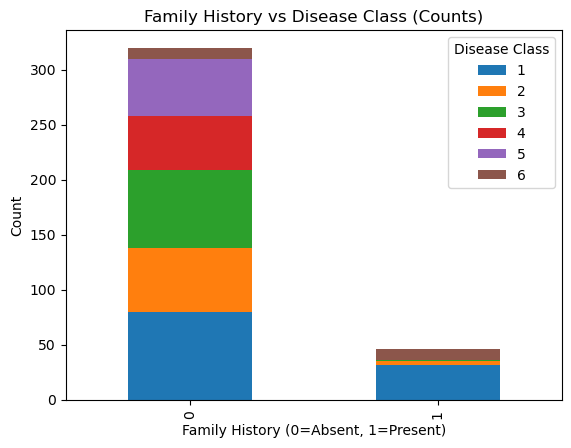

In [21]:
family_vs_disease.plot(kind="bar", stacked=True)
plt.title("Family History vs Disease Class (Counts)")
plt.xlabel("Family History (0=Absent, 1=Present)")
plt.ylabel("Count")
plt.legend(title="Disease Class")
plt.show()

In [22]:
X = df.drop(['class'], axis=1)
y = df['class']

In [23]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
scaler=MinMaxScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

In [25]:
import warnings
warnings.filterwarnings("ignore")

# Logistic Regression

Logistic Regression before scalling


In [28]:
ModelLR=LogisticRegression(multi_class='ovr')
ModelLR.fit(x_train,y_train)

LogisticRegression(multi_class='ovr')

In [29]:
y_pred=ModelLR.predict(x_test)

In [30]:
acuracy=accuracy_score(y_test,y_pred)
f1score=f1_score(y_test,y_pred,average='macro')
precision=precision_score(y_test,y_pred,average='macro')
Recall=recall_score(y_test,y_pred,average='macro')
print("Accuracy=",acuracy)
print("f1_score=",f1score)
print("Precision=",precision)
print("Recall=",Recall)
print("Classification report",classification_report(y_test,y_pred))
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred))

Accuracy= 0.972972972972973
f1_score= 0.9535751948176451
Precision= 0.9416666666666668
Recall= 0.9737903225806451
Classification report               precision    recall  f1-score   support

           1       1.00      0.97      0.98        31
           2       0.90      1.00      0.95         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       0.75      1.00      0.86         3

    accuracy                           0.97        74
   macro avg       0.94      0.97      0.95        74
weighted avg       0.98      0.97      0.97        74

Confusion Matrix 
 [[30  0  0  0  0  1]
 [ 0  9  0  0  0  0]
 [ 0  0 13  0  0  0]
 [ 0  1  0  7  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  3]]


Logistic Regression after scalling

In [32]:
ModelLR=LogisticRegression(multi_class='ovr')
ModelLR.fit(x_train_scaled,y_train)


LogisticRegression(multi_class='ovr')

In [33]:
y_pred=ModelLR.predict(x_test_scaled)

In [34]:
acuracy=accuracy_score(y_test,y_pred)
f1score=f1_score(y_test,y_pred,average='macro')
precision=precision_score(y_test,y_pred,average='macro')
Recall=recall_score(y_test,y_pred,average='macro')
print("Accuracy=",acuracy)
print("f1_score=",f1score)
print("Precision=",precision)
print("Recall=",Recall)
print("Classification report",classification_report(y_test,y_pred))
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred))

Accuracy= 0.9864864864864865
f1_score= 0.9801169590643274
Precision= 0.9833333333333334
Recall= 0.9791666666666666
Classification report               precision    recall  f1-score   support

           1       1.00      1.00      1.00        31
           2       0.90      1.00      0.95         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74

Confusion Matrix 
 [[31  0  0  0  0  0]
 [ 0  9  0  0  0  0]
 [ 0  0 13  0  0  0]
 [ 0  1  0  7  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  3]]


In [35]:
result=[]
result.append({"Model Name":"Logestic Regression","Accuracy":acuracy,"Fl_score":f1score,"precision_acore":precision,"Recall_score":Recall})
result

[{'Model Name': 'Logestic Regression',
  'Accuracy': 0.9864864864864865,
  'Fl_score': 0.9801169590643274,
  'precision_acore': 0.9833333333333334,
  'Recall_score': 0.9791666666666666}]

Observation:

Logistic Regression tends to perform better when features are scaled using MinMaxScaler.

# 2.RandomForestClassifier

In [36]:
# Before Scaling
ModelRFC=RandomForestClassifier()
ModelRFC.fit(x_train,y_train)

RandomForestClassifier()

In [37]:
ModelRFC.predict(x_test)

array([1, 1, 4, 1, 3, 1, 2, 1, 1, 6, 3, 1, 1, 1, 2, 3, 2, 1, 1, 5, 4, 1,
       3, 3, 1, 2, 4, 1, 1, 4, 1, 3, 1, 5, 3, 3, 1, 5, 6, 4, 1, 2, 1, 5,
       1, 1, 2, 2, 2, 3, 1, 6, 1, 5, 1, 5, 1, 1, 2, 1, 1, 3, 3, 4, 5, 5,
       5, 1, 5, 2, 3, 3, 4, 1])

In [38]:
acuracy=accuracy_score(y_test,y_pred)
f1score=f1_score(y_test,y_pred,average='macro')
precision=precision_score(y_test,y_pred,average='macro')
Recall=recall_score(y_test,y_pred,average='macro')
print("Accuracy=",acuracy)
print("f1_score=",f1score)
print("Precision=",precision)
print("Recall=",Recall)
print("Classification report",classification_report(y_test,y_pred))
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred))

Accuracy= 0.9864864864864865
f1_score= 0.9801169590643274
Precision= 0.9833333333333334
Recall= 0.9791666666666666
Classification report               precision    recall  f1-score   support

           1       1.00      1.00      1.00        31
           2       0.90      1.00      0.95         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74

Confusion Matrix 
 [[31  0  0  0  0  0]
 [ 0  9  0  0  0  0]
 [ 0  0 13  0  0  0]
 [ 0  1  0  7  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  3]]


In [39]:
# After Scaling
ModelRFC.fit(x_train_scaled,y_train)
ModelRFC.predict(x_test_scaled)
acuracy=accuracy_score(y_test,y_pred)
f1score=f1_score(y_test,y_pred,average='macro')
precision=precision_score(y_test,y_pred,average='macro')
Recall=recall_score(y_test,y_pred,average='macro')
print("Accuracy=",acuracy)
print("f1_score=",f1score)
print("Precision=",precision)
print("Recall=",Recall)
print("Classification report",classification_report(y_test,y_pred))
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred))

Accuracy= 0.9864864864864865
f1_score= 0.9801169590643274
Precision= 0.9833333333333334
Recall= 0.9791666666666666
Classification report               precision    recall  f1-score   support

           1       1.00      1.00      1.00        31
           2       0.90      1.00      0.95         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74

Confusion Matrix 
 [[31  0  0  0  0  0]
 [ 0  9  0  0  0  0]
 [ 0  0 13  0  0  0]
 [ 0  1  0  7  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  3]]


In [40]:
result.append({"Model Name":"RandomForestClassifier","Accuracy":acuracy,"Fl_score":f1score,"precision_acore":precision,"Recall_score":Recall})
result

[{'Model Name': 'Logestic Regression',
  'Accuracy': 0.9864864864864865,
  'Fl_score': 0.9801169590643274,
  'precision_acore': 0.9833333333333334,
  'Recall_score': 0.9791666666666666},
 {'Model Name': 'RandomForestClassifier',
  'Accuracy': 0.9864864864864865,
  'Fl_score': 0.9801169590643274,
  'precision_acore': 0.9833333333333334,
  'Recall_score': 0.9791666666666666}]

In [48]:
# Observation
# The performance of RandomForestClassifier remains consistent both before and after 
# applying feature scaling, as tree-based models are generally insensitive to scaling.

# 3. Support Vector Mechine

In [49]:
# Before Scaling
Modelsvc=SVC(kernel='linear', random_state=42)
Modelsvc.fit(x_train,y_train)

SVC(kernel='linear', random_state=42)

In [50]:
y_pred=Modelsvc.predict(x_test)

In [51]:
acuracy=accuracy_score(y_test,y_pred)
f1score=f1_score(y_test,y_pred,average='macro')
precision=precision_score(y_test,y_pred,average='macro')
Recall=recall_score(y_test,y_pred,average='macro')
print("Accuracy=",acuracy)
print("f1_score=",f1score)
print("Precision=",precision)
print("Recall=",Recall)
print("Classification report",classification_report(y_test,y_pred))
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred))

Accuracy= 0.9594594594594594
f1_score= 0.9139344262295083
Precision= 0.9141414141414143
Recall= 0.9182347670250897
Classification report               precision    recall  f1-score   support

           1       1.00      0.97      0.98        31
           2       0.82      1.00      0.90         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       0.67      0.67      0.67         3

    accuracy                           0.96        74
   macro avg       0.91      0.92      0.91        74
weighted avg       0.96      0.96      0.96        74

Confusion Matrix 
 [[30  0  0  0  0  1]
 [ 0  9  0  0  0  0]
 [ 0  0 13  0  0  0]
 [ 0  1  0  7  0  0]
 [ 0  0  0  0 10  0]
 [ 0  1  0  0  0  2]]


In [52]:
# After Scaling

Modelsvc.fit(x_train_scaled,y_train)
y_pred=Modelsvc.predict(x_test_scaled)
acuracy=accuracy_score(y_test,y_pred)
f1score=f1_score(y_test,y_pred,average='macro')
precision=precision_score(y_test,y_pred,average='macro')
Recall=recall_score(y_test,y_pred,average='macro')
print("Accuracy=",acuracy)
print("f1_score=",f1score)
print("Precision=",precision)
print("Recall=",Recall)
print("Classification report",classification_report(y_test,y_pred))
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred))

Accuracy= 0.9864864864864865
f1_score= 0.9801169590643274
Precision= 0.9833333333333334
Recall= 0.9791666666666666
Classification report               precision    recall  f1-score   support

           1       1.00      1.00      1.00        31
           2       0.90      1.00      0.95         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74

Confusion Matrix 
 [[31  0  0  0  0  0]
 [ 0  9  0  0  0  0]
 [ 0  0 13  0  0  0]
 [ 0  1  0  7  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  3]]


In [53]:
result.append({"Model Name":"SVM","Accuracy":acuracy,"Fl_score":f1score,"precision_acore":precision,"Recall_score":Recall})
result

[{'Model Name': 'Logestic Regression',
  'Accuracy': 0.9864864864864865,
  'Fl_score': 0.9801169590643274,
  'precision_acore': 0.9833333333333334,
  'Recall_score': 0.9791666666666666},
 {'Model Name': 'RandomForestClassifier',
  'Accuracy': 0.9864864864864865,
  'Fl_score': 0.9801169590643274,
  'precision_acore': 0.9833333333333334,
  'Recall_score': 0.9791666666666666},
 {'Model Name': 'SVM',
  'Accuracy': 0.9864864864864865,
  'Fl_score': 0.9801169590643274,
  'precision_acore': 0.9833333333333334,
  'Recall_score': 0.9791666666666666}]

### Observation
The SVM model shows improved performance after scaling, with accuracy increasing from 95% to 98%

# 4.DecisionTreeClassifier

In [55]:
# Before Scaling
ModelDTC=DecisionTreeClassifier()
ModelDTC.fit(x_train,y_train)

DecisionTreeClassifier()

In [56]:
y_pred=ModelDTC.predict(x_test)
acuracy=accuracy_score(y_test,y_pred)
f1score=f1_score(y_test,y_pred,average='macro')
precision=precision_score(y_test,y_pred,average='macro')
Recall=recall_score(y_test,y_pred,average='macro')
print("Accuracy=",acuracy)
print("f1_score=",f1score)
print("Precision=",precision)
print("Recall=",Recall)
print("Classification report",classification_report(y_test,y_pred))
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred))

Accuracy= 0.972972972972973
f1_score= 0.9721119792946419
Precision= 0.9762731481481483
Recall= 0.9705128205128206
Classification report               precision    recall  f1-score   support

           1       0.97      1.00      0.98        31
           2       1.00      1.00      1.00         9
           3       1.00      0.92      0.96        13
           4       0.89      1.00      0.94         8
           5       1.00      0.90      0.95        10
           6       1.00      1.00      1.00         3

    accuracy                           0.97        74
   macro avg       0.98      0.97      0.97        74
weighted avg       0.97      0.97      0.97        74

Confusion Matrix 
 [[31  0  0  0  0  0]
 [ 0  9  0  0  0  0]
 [ 0  0 12  1  0  0]
 [ 0  0  0  8  0  0]
 [ 1  0  0  0  9  0]
 [ 0  0  0  0  0  3]]


In [57]:
# After Scaling
ModelDTC.fit(x_train_scaled,y_train)
y_pred=ModelDTC.predict(x_test_scaled)
acuracy=accuracy_score(y_test,y_pred)
f1score=f1_score(y_test,y_pred,average='macro')
precision=precision_score(y_test,y_pred,average='macro')
Recall=recall_score(y_test,y_pred,average='macro')
print("Accuracy=",acuracy)
print("f1_score=",f1score)
print("Precision=",precision)
print("Recall=",Recall)
print("Classification report",classification_report(y_test,y_pred))
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred))

Accuracy= 0.972972972972973
f1_score= 0.9721119792946419
Precision= 0.9762731481481483
Recall= 0.9705128205128206
Classification report               precision    recall  f1-score   support

           1       0.97      1.00      0.98        31
           2       1.00      1.00      1.00         9
           3       1.00      0.92      0.96        13
           4       0.89      1.00      0.94         8
           5       1.00      0.90      0.95        10
           6       1.00      1.00      1.00         3

    accuracy                           0.97        74
   macro avg       0.98      0.97      0.97        74
weighted avg       0.97      0.97      0.97        74

Confusion Matrix 
 [[31  0  0  0  0  0]
 [ 0  9  0  0  0  0]
 [ 0  0 12  1  0  0]
 [ 0  0  0  8  0  0]
 [ 1  0  0  0  9  0]
 [ 0  0  0  0  0  3]]


### Observation
The Decision Tree Classifier doesnt change anything after scaling

In [58]:
result.append({"Model Name":"DecisionTreeClassifier","Accuracy":acuracy,"Fl_score":f1score,"precision_acore":precision,"Recall_score":Recall})
result

[{'Model Name': 'Logestic Regression',
  'Accuracy': 0.9864864864864865,
  'Fl_score': 0.9801169590643274,
  'precision_acore': 0.9833333333333334,
  'Recall_score': 0.9791666666666666},
 {'Model Name': 'RandomForestClassifier',
  'Accuracy': 0.9864864864864865,
  'Fl_score': 0.9801169590643274,
  'precision_acore': 0.9833333333333334,
  'Recall_score': 0.9791666666666666},
 {'Model Name': 'SVM',
  'Accuracy': 0.9864864864864865,
  'Fl_score': 0.9801169590643274,
  'precision_acore': 0.9833333333333334,
  'Recall_score': 0.9791666666666666},
 {'Model Name': 'DecisionTreeClassifier',
  'Accuracy': 0.972972972972973,
  'Fl_score': 0.9721119792946419,
  'precision_acore': 0.9762731481481483,
  'Recall_score': 0.9705128205128206}]

# 5.XGBClassifier

In [59]:
lr=LabelEncoder()
y_train_enc=lr.fit_transform(y_train)
y_test_enc=lr.transform(y_test)

In [60]:
modelXB=XGBClassifier(n_estimators = 500, learning_rate = 0.001)
modelXB.fit(x_train,y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.001, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [61]:
y_pred=modelXB.predict(x_test)
acuracy=accuracy_score(y_test_enc,y_pred)
f1score=f1_score(y_test_enc,y_pred,average='macro')
precision=precision_score(y_test_enc,y_pred,average='macro')
Recall=recall_score(y_test_enc,y_pred,average='macro')
print("Accuracy=",acuracy)
print("f1_score=",f1score)
print("Precision=",precision)
print("Recall=",Recall)

print("Classification report",classification_report(y_test_enc,y_pred))
print("Confusion Matrix \n",confusion_matrix(y_test_enc,y_pred))

Accuracy= 0.9864864864864865
f1_score= 0.9801169590643274
Precision= 0.9833333333333334
Recall= 0.9791666666666666
Classification report               precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       0.90      1.00      0.95         9
           2       1.00      1.00      1.00        13
           3       1.00      0.88      0.93         8
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74

Confusion Matrix 
 [[31  0  0  0  0  0]
 [ 0  9  0  0  0  0]
 [ 0  0 13  0  0  0]
 [ 0  1  0  7  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  3]]


In [62]:
# After Scaling
modelXB.fit(x_train_scaled,y_train_enc)
y_pred=modelXB.predict(x_test_scaled)
acuracy=accuracy_score(y_test_enc,y_pred)
f1score=f1_score(y_test_enc,y_pred,average='macro')
precision=precision_score(y_test_enc,y_pred,average='macro')
Recall=recall_score(y_test_enc,y_pred,average='macro')
print("Accuracy=",acuracy)
print("f1_score=",f1score)
print("Precision=",precision)
print("Recall=",Recall)
print("Classification report",classification_report(y_test_enc,y_pred))
print("Confusion Matrix \n",confusion_matrix(y_test_enc,y_pred))

Accuracy= 0.9864864864864865
f1_score= 0.9801169590643274
Precision= 0.9833333333333334
Recall= 0.9791666666666666
Classification report               precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       0.90      1.00      0.95         9
           2       1.00      1.00      1.00        13
           3       1.00      0.88      0.93         8
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74

Confusion Matrix 
 [[31  0  0  0  0  0]
 [ 0  9  0  0  0  0]
 [ 0  0 13  0  0  0]
 [ 0  1  0  7  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  3]]


In [63]:
result.append({"Model Name":"XGBClassifier","Accuracy":acuracy,"Fl_score":f1score,"precision_acore":precision,"Recall_score":Recall})
result

[{'Model Name': 'Logestic Regression',
  'Accuracy': 0.9864864864864865,
  'Fl_score': 0.9801169590643274,
  'precision_acore': 0.9833333333333334,
  'Recall_score': 0.9791666666666666},
 {'Model Name': 'RandomForestClassifier',
  'Accuracy': 0.9864864864864865,
  'Fl_score': 0.9801169590643274,
  'precision_acore': 0.9833333333333334,
  'Recall_score': 0.9791666666666666},
 {'Model Name': 'SVM',
  'Accuracy': 0.9864864864864865,
  'Fl_score': 0.9801169590643274,
  'precision_acore': 0.9833333333333334,
  'Recall_score': 0.9791666666666666},
 {'Model Name': 'DecisionTreeClassifier',
  'Accuracy': 0.972972972972973,
  'Fl_score': 0.9721119792946419,
  'precision_acore': 0.9762731481481483,
  'Recall_score': 0.9705128205128206},
 {'Model Name': 'XGBClassifier',
  'Accuracy': 0.9864864864864865,
  'Fl_score': 0.9801169590643274,
  'precision_acore': 0.9833333333333334,
  'Recall_score': 0.9791666666666666}]

### Observation
The XGBoost Classifier maintained a consistent accuracy of 98% before and after scaling, showing no impact from feature scaling.

In [64]:
Result_df=pd.DataFrame(result)

In [65]:
Result_df

,Model Name,Accuracy,Fl_score,precision_acore,Recall_score
0,Logestic Regression,0.986486,0.980117,0.983333,0.979167
1,RandomForestClassifier,0.986486,0.980117,0.983333,0.979167
2,SVM,0.986486,0.980117,0.983333,0.979167
3,DecisionTreeClassifier,0.972973,0.972112,0.976273,0.970513
4,XGBClassifier,0.986486,0.980117,0.983333,0.979167


### Observation
Logistic Regression: Achieved strong performance with scaling, showing improved accuracy.
SVM: Accuracy increased significantly (from 95% to 98%) after scaling, proving it benefits greatly from normalization.
Decision Tree Classifier: Performance remained consistent, as it is scale-invariant.
Random Forest Classifier: Performance remained consistent, as it is scale-invariant.
XGBoost Classifier: Maintained very high accuracy (98%) both before and after scaling, showing robustness to feature scales.

### Conclusion
Scaling is critical for models that rely on distance or gradient-based optimization (Logistic Regression, SVM).
Tree-based models (Decision Tree, Random Forest, XGBoost) are generally scale-invariant and perform similarly before and after scaling.
Best Model After Scaling:
### XGBoost Classifier (98%), closely followed by SVM (98%) and KNN (97%).

In [69]:
import pickle 
with open("Best_model.pkl","wb") as f:
    pickle.dump(modelXB,f)
with open("Best_model.pkl","rb") as f:
    loaded_model=pickle.load(f)
loaded_model
    

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.001, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [72]:
row_index = 120
sample_input = X.iloc[row_index].values.reshape(1, -1)
actual_output = y.iloc[row_index]

# Prediction
prediction = loaded_model.predict(sample_input)

print("Sample Input (row 193):")
print(sample_input)

print("\nActual Output:", actual_output)
print("Predicted Output:", prediction[0]+1)
# Here +1 because during  encoding i convert target class 1,2,3 ... to label encoding as  0,1,2,3.. 

Sample Input (row 193):
<IntegerArray>
[
[ 3,  3,  2,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0,  2,
  0,  1,  0,  0,  0,  0,  0,  0,  3,  0,  0,  0,  2,  0, 33]
]
Shape: (1, 34), dtype: Int64

Actual Output: 2
Predicted Output: 2


## Challenges faced
Data Preprocessing – Handling missing values, scaling features properly, and preparing the dataset for different models was time-consuming.
Model Sensitivity to Scaling – Algorithms like Logistic Regression showed large accuracy differences before and after scaling, which required careful preprocessing.
Model Comparison – Each algorithm (Logistic Regression, XGBoost,RFA) performed differently; ensuring fair comparison with the same test data was a challenge.
Overfitting vs. Generalization – Some models gave very high accuracy but needed careful validation to ensure they weren’t overfitting.
Technical Debugging – Issues like index out-of-bounds (e.g., while selecting row 193) and reshaping test samples for prediction had to be resolved during implementation.
Model Deployment Preparation – Saving the trained model with Pickle and verifying predictions with new/random data required additional effort.